# Import Necessary Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('Medical Insurance Price CSV.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
"""
About the Dataset:
age: age of the insured person (numeric)
sex: gender of the insured person (categorical: male/female)
bmi: body mass index of the insured person (numeric)
children: number of children covered by the insurance plan(numeric)
smoker: whether or not the insured person is a smoker (categorical: yes/no)
region: region where the insured person reside (categorical: northest/northwest/southeast/southwest)
charges: the insurance charges/costs billed to the insured person(numeric)
"""

'\nAbout the Dataset:\nage: age of the insured person (numeric)\nsex: gender of the insured person (categorical: male/female)\nbmi: body mass index of the insured person (numeric)\nchildren: number of children covered by the insurance plan(numeric)\nsmoker: whether or not the insured person is a smoker (categorical: yes/no)\nregion: region where the insured person reside (categorical: northest/northwest/southeast/southwest)\ncharges: the insurance charges/costs billed to the insured person(numeric)\n'

# EDA: Exploration Data Analytics

In [5]:
df.shape

(1338, 7)

In [6]:
#the check the datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
#The above dataset has n object datatype so we need to do conversion from object to integer

In [9]:
#To check the statistical info
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Data Visualisation

<Figure size 300x300 with 0 Axes>

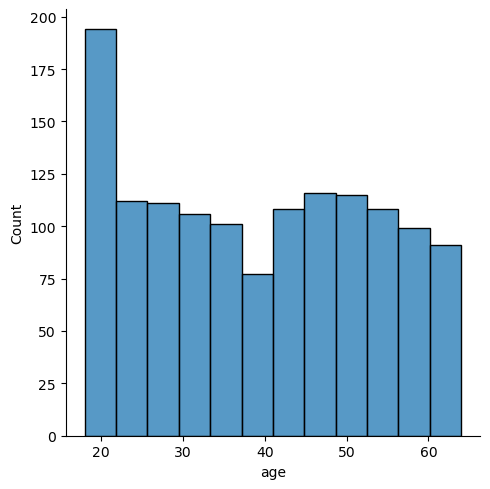

In [12]:
plt.figure(figsize=(3,3))
sns.displot(data=df,x='age')#x='sex',x='bmi'

In [13]:
df['sex'].value_counts()

male      676
female    662
Name: sex, dtype: int64

In [14]:
df['children'].value_counts()

0    574
1    324
2    240
3    157
4     25
5     18
Name: children, dtype: int64

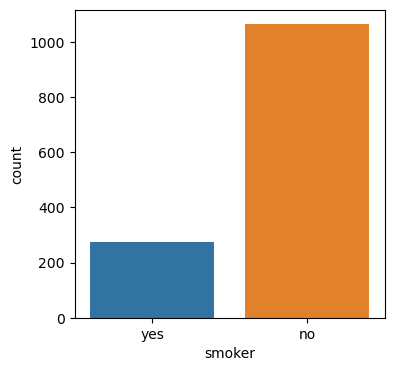

In [15]:
#distribution for smokers
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='smoker')
plt.show()

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
#Note: sex, smoke and region are label, machine can't understand it so need to covnert it to number/numerical value
df['sex'].value_counts()

male      676
female    662
Name: sex, dtype: int64

In [19]:
df['smoker'].value_counts()

no     1064
yes     274
Name: smoker, dtype: int64

In [20]:
df['region'].value_counts()

southeast    364
southwest    325
northwest    325
northeast    324
Name: region, dtype: int64

## Convert categorical column to numerical

In [21]:
#Trick
df.replace({'sex':{'male':0,'female':1}}, inplace=True)
df.replace({'smoker':{'yes':0,'no':1}},inplace=True)
df.replace({'region':{'southeast':0,'southwest':1,'northwest':2,'northeast':3}},inplace=True)

In [22]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,2,21984.47061
4,32,0,28.880,0,1,2,3866.85520


In [25]:
#Train test split
X = df.drop('charges', axis=1)
y = df['charges']


In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=2)

In [28]:
X_train.shape

(1204, 6)

In [30]:
X_test.shape

(134, 6)

In [31]:
#Model for training
lg = LinearRegression()
lg.fit(X_train,y_train)#80 model will be train

LinearRegression()

In [32]:
#prediciton on test set
y_pred = lg.predict(X_test)
y_pred

array([ 1831.00128056, 12159.15610236, 10221.02957304,  1931.07889605,
        7708.32210916, 11362.71453869,  3226.18930032,  1380.14055226,
       12078.1278645 ,  9545.09206883, 11588.58647378,  5076.08579737,
       29657.97519822,  -722.90554201, 13063.66673311, 12602.30411806,
        4123.86093137,  7880.72658343, 28931.66363323,  3162.51691839,
       12519.748324  ,  2325.26699456, 34097.77374993, 32372.92091451,
       30147.66200688,  8594.13929241,  2529.58894932, 14902.45791073,
        6774.11912654,  2106.22614057,  9676.06641324,  5885.77299598,
        4266.22715745,  4644.67563944,  8608.61245099,  4914.24229626,
       30388.93753313,  6648.21466294, 27758.66407963, 13489.6156729 ,
         351.44237387, 28512.30416636,  7877.24048384,  1639.50750102,
       10302.9694382 ,  8050.16026729, 10992.48504884,  8023.50359127,
       10611.84955849, 13729.01898728,  5679.73245484,  -998.98532889,
       26638.5613963 , 37076.22859917,  7350.96806601, 18098.78497121,
      

In [33]:
#Evaluation
r2_score(y_test,y_pred)

0.7058997983752826

# Prediction System

In [34]:
input_df = (19,1,27.900,0,0,1)
np_df = np.asarray(input_df)
input_df_reshaped = np_df.reshape(1,-1)
prediction = lg.predict(input_df_reshaped)
print("Medical Insurance is:",prediction)

Medical Insurance is: [25925.06977975]


C:\Users\CSC\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
